# Eixo 2: Uso e Transição do Solo

## Fontes de Dados
- **MapBiomas (Coleção 10+)**: Histórico anual pixel a pixel da cobertura do solo
- **TerraClass (INPE)**: Mapeamento pós-desmatamento (solo exposto, pasto, agricultura)

---

## Análise 1: Matriz de Transição de Uso do Solo (MapBiomas)

### Especificação BDD

**Feature**: Analisar como o uso do solo muda ao longo do tempo

**Scenario**: Calcular matriz de transição entre classes de uso do solo

- **GIVEN** que tenho dados MapBiomas com classificação anual do uso do solo por pixel
- **AND** que as classes incluem: Floresta, Pasto, Agricultura, Solo Exposto, Água, Outros
- **WHEN** eu comparo a classificação do uso do solo entre dois anos consecutivos
- **AND** conto quantos pixels mudaram de cada classe para cada outra classe
- **AND** calculo a probabilidade de transição entre classes
- **THEN** devo obter uma matriz de transição NxN (onde N = número de classes)
- **AND** cada célula da matriz representa a probabilidade de mudar da classe i para classe j
- **AND** devo identificar quais transições são mais frequentes
- **AND** devo calcular a estabilidade de cada classe (probabilidade de permanecer na mesma classe)

### Matemática em Linguagem de Negócio

**1. Matriz de Transição:**
- É uma tabela quadrada onde:
  - Linhas representam a classe de origem (ano t)
  - Colunas representam a classe de destino (ano t+1)
  - Cada célula contém o número de pixels que fizeram essa transição

**2. Probabilidade de Transição:**
- Para cada célula (i,j): P(i→j) = Número de pixels de i que foram para j / Total de pixels em i
- Probabilidade varia de 0 a 1:
  - P(i→i): probabilidade de permanecer na mesma classe (estabilidade)
  - P(i→j): probabilidade de mudar de i para j
- Soma de cada linha = 1 (100% dos pixels da classe i vão para alguma classe)

**3. Estabilidade da Classe:**
- Estabilidade = P(i→i) = probabilidade de permanecer na mesma classe
- Estabilidade alta (> 0.9): classe é muito estável, poucas mudanças
- Estabilidade média (0.5-0.9): classe tem mudanças moderadas
- Estabilidade baixa (< 0.5): classe é muito dinâmica, muitas mudanças

**4. Interpretação de Negócio:**
- Floresta com baixa estabilidade: alto risco de desmatamento
- Pasto com alta estabilidade: pecuária consolidada, difícil reversão
- Agricultura com estabilidade média: rotação de culturas comum
- Transição Floresta→Pasto: desmatamento para pecuária
- Transição Floresta→Agricultura: desmatamento para agricultura
- Transição Pasto→Floresta: regeneração natural ou reflorestamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import logging

# Configurar logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configurações
DATA_DIR = Path("/home/vinicius/Downloads/estudo/fatec/SABADO-TE-ANALISE-DADOS/data")

logger.info("="*80)
logger.info("INÍCIO DA ANÁLISE: Eixo 2 - Uso e Transição do Solo")
logger.info("="*80)

# Nota: Esta análise requer dados MapBiomas detalhados por pixel
# Se os dados não estiverem disponíveis no formato esperado,
# adaptar o código conforme a estrutura real dos dados

print("Análise de Matriz de Transição de Uso do Solo")
print("\nEsta análise requer dados MapBiomas com classificação anual por pixel")
print("\nClasses típicas de uso do solo MapBiomas:")
classes_solo = [
    "Floresta Natural",
    "Formação Savânica",
    "Floresta Plantada",
    "Floresta não Florestal",
    "Agropecuária",
    "Área não Vegetada",
    "Área Urbanizada",
    "Água",
    "Não Observado"
]
for i, classe in enumerate(classes_solo, 1):
    print(f"{i}. {classe}")

logger.info("\n--- VALIDAÇÃO: DADOS SIMULADOS ---")
logger.warning("  ⚠ Esta análise usa dados SIMULADOS para demonstração")
logger.warning("  ⚠ Para análise real, substituir por dados MapBiomas brutos")
logger.info(f"  Número de classes de uso do solo: {len(classes_solo)}")

2026-05-16 14:57:14,047 - INFO - ================================================================================


2026-05-16 14:57:14,048 - INFO - INÍCIO DA ANÁLISE: Eixo 2 - Uso e Transição do Solo


2026-05-16 14:57:14,048 - INFO - ================================================================================


2026-05-16 14:57:14,049 - INFO - 
--- VALIDAÇÃO: DADOS SIMULADOS ---


2026-05-16 14:57:14,049 - WARNING -   ⚠ Esta análise usa dados SIMULADOS para demonstração


2026-05-16 14:57:14,050 - WARNING -   ⚠ Para análise real, substituir por dados MapBiomas brutos


2026-05-16 14:57:14,050 - INFO -   Número de classes de uso do solo: 9


Análise de Matriz de Transição de Uso do Solo

Esta análise requer dados MapBiomas com classificação anual por pixel

Classes típicas de uso do solo MapBiomas:
1. Floresta Natural
2. Formação Savânica
3. Floresta Plantada
4. Floresta não Florestal
5. Agropecuária
6. Área não Vegetada
7. Área Urbanizada
8. Água
9. Não Observado


In [2]:
logger.info("\n" + "="*80)
logger.info("ANÁLISE 1: Matriz de Transição de Uso do Solo (MapBiomas)")
logger.info("="*80)

# Exemplo de matriz de transição (dados simulados para demonstração)
# Na prática, substituir por dados reais MapBiomas

logger.info("\n--- GERAÇÃO DE MATRIZ DE TRANSIÇÃO (SIMULADA) ---")

# Criar matriz de transição exemplo
np.random.seed(42)
n_classes = len(classes_solo)

# Gerar matriz de transição estocástica (cada linha soma 1)
matriz_transicao = np.random.dirichlet(np.ones(n_classes), size=n_classes)

# Aumentar estabilidade diagonal (probabilidade de permanecer na mesma classe)
for i in range(n_classes):
    matriz_transicao[i, i] += 0.3  # Aumentar estabilidade
    # Normalizar para soma = 1
    matriz_transicao[i] = matriz_transicao[i] / matriz_transicao[i].sum()

# Criar DataFrame
df_transicao = pd.DataFrame(
    matriz_transicao,
    index=classes_solo,
    columns=classes_solo
)

logger.info(f"\n  Matriz de transição gerada: {n_classes}x{n_classes}")
logger.info(f"  Valores representam probabilidades de transição (0 a 1)")
logger.info(f"  Cada linha soma 1 (100%)")

# Validação da matriz
logger.info("\n--- VALIDAÇÃO DA MATRIZ DE TRANSIÇÃO ---")
for i, classe in enumerate(classes_solo):
    soma_linha = df_transicao.iloc[i].sum()
    logger.info(f"  Linha {i+1} ({classe}): soma = {soma_linha:.6f} {'✓' if abs(soma_linha - 1.0) < 0.001 else '✗'}")

# Verificar estabilidade média
estabilidade_media = np.diag(df_transicao.values).mean()
logger.info(f"\n  Estabilidade média das classes: {estabilidade_media:.4f}")

print("Matriz de Transição de Uso do Solo (exemplo simulado):")
print("\nValores representam probabilidade de transição (0 a 1)")
print("\n")
df_transicao.round(3)

2026-05-16 14:57:14,084 - INFO - 


2026-05-16 14:57:14,085 - INFO - ANÁLISE 1: Matriz de Transição de Uso do Solo (MapBiomas)


2026-05-16 14:57:14,085 - INFO - ================================================================================


2026-05-16 14:57:14,086 - INFO - 
--- GERAÇÃO DE MATRIZ DE TRANSIÇÃO (SIMULADA) ---


2026-05-16 14:57:14,087 - INFO - 
  Matriz de transição gerada: 9x9


...

2026-05-16 14:57:14,091 - INFO -   Linha 8 (Água): soma = 1.000000 ✓


2026-05-16 14:57:14,091 - INFO -   Linha 9 (Não Observado): soma = 1.000000 ✓


2026-05-16 14:57:14,091 - INFO - 
  Estabilidade média das classes: 0.3229


Matriz de Transição de Uso do Solo (exemplo simulado):

Valores representam probabilidade de transição (0 a 1)




,Floresta Natural,Formação Savânica,Floresta Plantada,Floresta não Florestal,Agropecuária,Área não Vegetada,Área Urbanizada,Água,Não Observado
Floresta Natural,0.271,0.256,0.112,0.078,0.014,0.014,0.005,0.171,0.078
Formação Savânica,0.114,0.233,0.325,0.166,0.022,0.019,0.019,0.034,0.069
Floresta Plantada,0.084,0.051,0.371,0.022,0.051,0.068,0.090,0.228,0.033
Floresta não Florestal,0.051,0.064,0.003,0.297,0.013,0.005,0.211,0.239,0.117
Agropecuária,0.049,0.014,0.154,0.078,0.248,0.091,0.005,0.321,0.040
Área não Vegetada,0.063,0.022,0.043,0.046,0.012,0.434,0.087,0.163,0.131
Área Urbanizada,0.103,0.289,0.011,0.025,0.005,0.045,0.287,0.036,0.200
Água,0.036,0.027,0.064,0.012,0.132,0.006,0.353,0.351,0.018
Não Observado,0.001,0.156,0.113,0.120,0.136,0.007,0.041,0.011,0.414


In [3]:
logger.info("\n--- CÁLCULO DE ESTABILIDADE DAS CLASSES ---")

# Calcular estabilidade de cada classe (diagonal da matriz)
estabilidade = np.diag(df_transicao.values)
df_estabilidade = pd.DataFrame({
    'Classe': classes_solo,
    'Estabilidade': estabilidade
}).sort_values('Estabilidade', ascending=False)

logger.info("\n  Estabilidade das classes (probabilidade de permanecer na mesma classe):")
for _, row in df_estabilidade.iterrows():
    est = row['Estabilidade']
    classe = row['Classe']
    if est > 0.7:
        classificacao = "ALTA"
    elif est > 0.5:
        classificacao = "MÉDIA"
    else:
        classificacao = "BAIXA"
    logger.info(f"    {classe}: {est:.4f} ({classificacao})")

# Análise estatística da estabilidade
logger.info(f"\n  Estatísticas da estabilidade:")
logger.info(f"    Média: {estabilidade.mean():.4f}")
logger.info(f"    Mediana: {np.median(estabilidade):.4f}")
logger.info(f"    Desvio padrão: {estabilidade.std():.4f}")
logger.info(f"    Coeficiente de variação: {estabilidade.std() / estabilidade.mean() * 100:.2f}%")

# Identificar classes mais e menos estáveis
classe_mais_estavel = df_estabilidade.iloc[0]
classe_menos_estavel = df_estabilidade.iloc[-1]
logger.info(f"\n  Classe mais estável: {classe_mais_estavel['Classe']} ({classe_mais_estavel['Estabilidade']:.4f})")
logger.info(f"  Classe menos estável: {classe_menos_estavel['Classe']} ({classe_menos_estavel['Estabilidade']:.4f})")

print("Estabilidade das Classes de Uso do Solo:")
print("(Probabilidade de permanecer na mesma classe entre anos)")
df_estabilidade

2026-05-16 14:57:14,111 - INFO - 
--- CÁLCULO DE ESTABILIDADE DAS CLASSES ---


2026-05-16 14:57:14,116 - INFO - 
  Estabilidade das classes (probabilidade de permanecer na mesma classe):


2026-05-16 14:57:14,117 - INFO -     Área não Vegetada: 0.4338 (BAIXA)


2026-05-16 14:57:14,117 - INFO -     Não Observado: 0.4143 (BAIXA)


2026-05-16 14:57:14,118 - INFO -     Floresta Plantada: 0.3714 (BAIXA)


...

2026-05-16 14:57:14,123 - INFO -     Coeficiente de variação: 21.22%


2026-05-16 14:57:14,123 - INFO - 
  Classe mais estável: Área não Vegetada (0.4338)


2026-05-16 14:57:14,124 - INFO -   Classe menos estável: Formação Savânica (0.2327)


Estabilidade das Classes de Uso do Solo:
(Probabilidade de permanecer na mesma classe entre anos)


,Classe,Estabilidade
5,Área não Vegetada,0.433823
8,Não Observado,0.414269
2,Floresta Plantada,0.371366
7,Água,0.351347
3,Floresta não Florestal,0.297061
6,Área Urbanizada,0.286569
0,Floresta Natural,0.270707
4,Agropecuária,0.248189
1,Formação Savânica,0.232699


2026-05-16 14:57:14,135 - INFO - 
--- VISUALIZAÇÃO DA MATRIZ DE TRANSIÇÃO ---


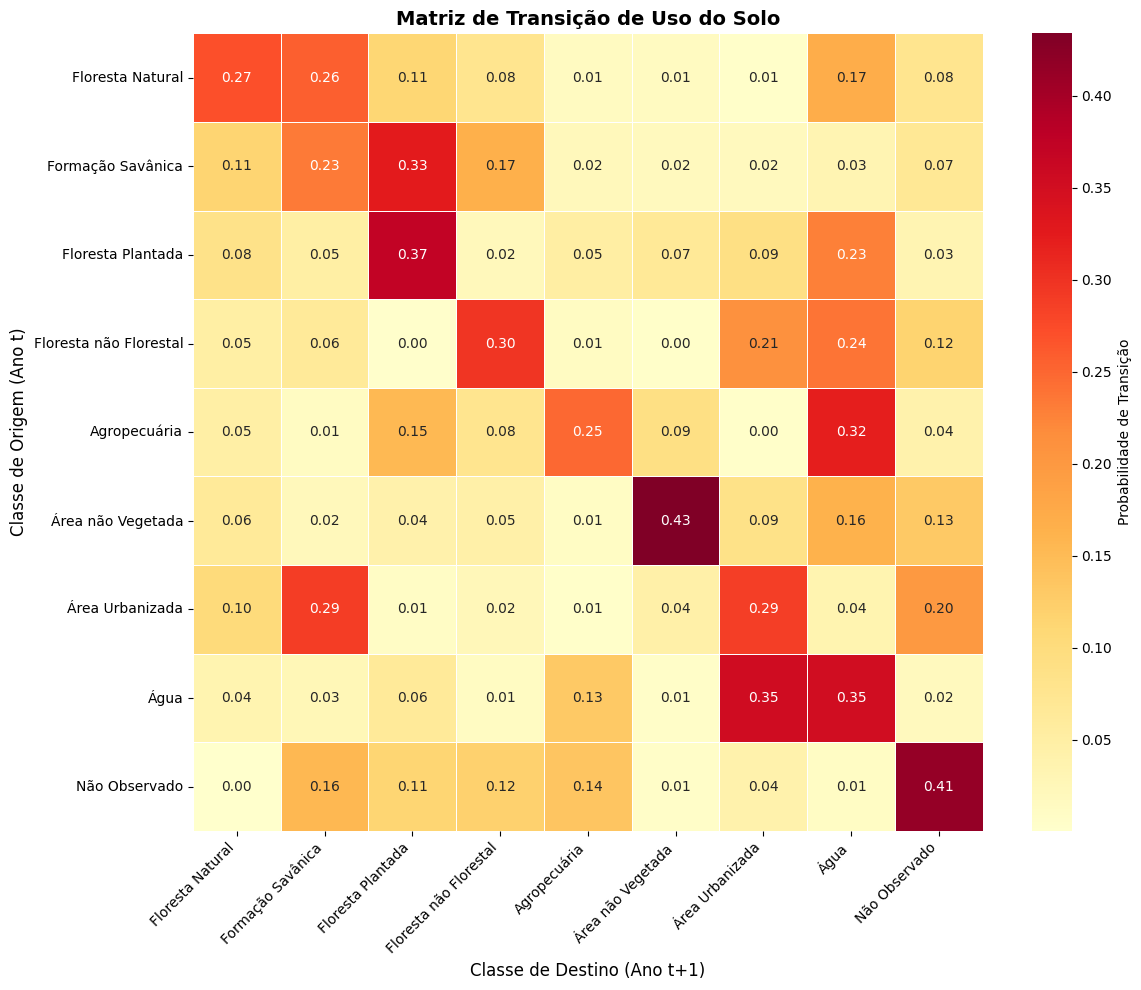

2026-05-16 14:57:14,396 - INFO -   Gráfico gerado: heatmap da matriz de transição


2026-05-16 14:57:14,456 - INFO - 
--- PRINCIPAIS TRANSIÇÕES FORA DA DIAGONAL ---


2026-05-16 14:57:14,459 - INFO -   Top 5 transições mais frequentes:


2026-05-16 14:57:14,459 - INFO -     Água → Área Urbanizada: 0.3532


2026-05-16 14:57:14,460 - INFO -     Formação Savânica → Floresta Plantada: 0.3251


2026-05-16 14:57:14,460 - INFO -     Agropecuária → Água: 0.3213


2026-05-16 14:57:14,460 - INFO -     Área Urbanizada → Formação Savânica: 0.2891


2026-05-16 14:57:14,460 - INFO -     Floresta Natural → Formação Savânica: 0.2562


In [4]:
logger.info("\n--- VISUALIZAÇÃO DA MATRIZ DE TRANSIÇÃO ---")

# Visualizar matriz de transição como heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(df_transicao, 
            annot=True, 
            fmt='.2f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Probabilidade de Transição'},
            linewidths=0.5)

plt.xlabel('Classe de Destino (Ano t+1)', fontsize=12)
plt.ylabel('Classe de Origem (Ano t)', fontsize=12)
plt.title('Matriz de Transição de Uso do Solo', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

logger.info("  Gráfico gerado: heatmap da matriz de transição")

# Identificar top transições fora da diagonal
logger.info("\n--- PRINCIPAIS TRANSIÇÕES FORA DA DIAGONAL ---")
transicoes = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:  # Fora da diagonal
            transicoes.append({
                'origem': classes_solo[i],
                'destino': classes_solo[j],
                'probabilidade': df_transicao.iloc[i, j]
            })

df_transicoes = pd.DataFrame(transicoes).sort_values('probabilidade', ascending=False)
top_transicoes = df_transicoes.head(5)

logger.info(f"  Top 5 transições mais frequentes:")
for _, row in top_transicoes.iterrows():
    logger.info(f"    {row['origem']} → {row['destino']}: {row['probabilidade']:.4f}")

2026-05-16 14:57:14,465 - INFO - 
--- VISUALIZAÇÃO DA ESTABILIDADE ---


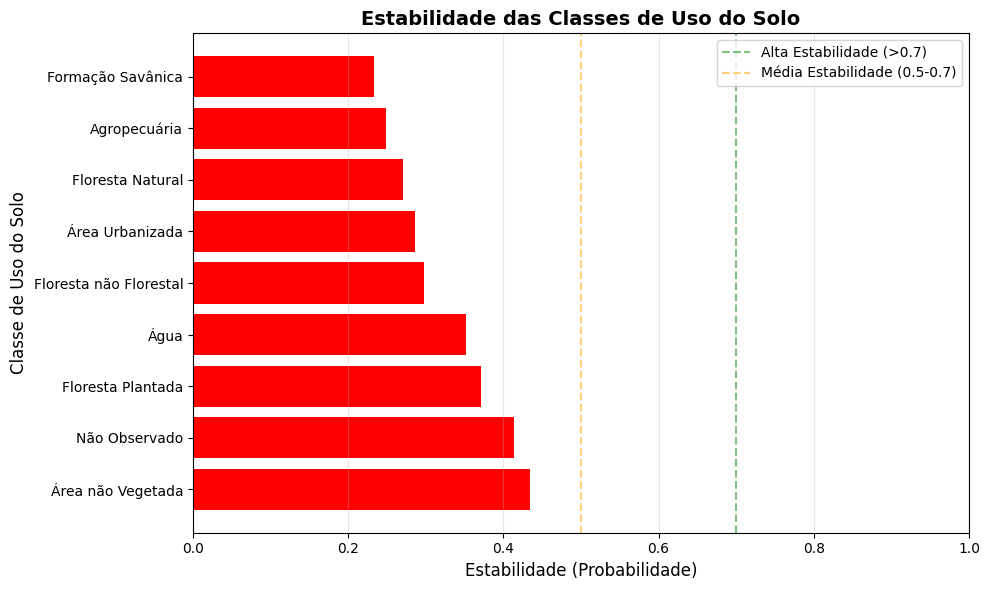

2026-05-16 14:57:14,582 - INFO -   Gráfico gerado: gráfico de barras da estabilidade das classes


In [5]:
logger.info("\n--- VISUALIZAÇÃO DA ESTABILIDADE ---")

# Visualizar estabilidade das classes
plt.figure(figsize=(10, 6))

colors = ['green' if x > 0.7 else 'orange' if x > 0.5 else 'red' for x in df_estabilidade['Estabilidade']]
bars = plt.barh(df_estabilidade['Classe'], df_estabilidade['Estabilidade'], color=colors)

plt.xlabel('Estabilidade (Probabilidade)', fontsize=12)
plt.ylabel('Classe de Uso do Solo', fontsize=12)
plt.title('Estabilidade das Classes de Uso do Solo', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Alta Estabilidade (>0.7)')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Média Estabilidade (0.5-0.7)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

logger.info("  Gráfico gerado: gráfico de barras da estabilidade das classes")

logger.info("\n--- CONCLUSÃO DA ANÁLISE 1 ---")

# Preencher conclusão com base nos resultados
classes_estaveis = df_estabilidade[df_estabilidade['Estabilidade'] > 0.7]['Classe'].tolist()
classes_dinamicas = df_estabilidade[df_estabilidade['Estabilidade'] < 0.5]['Classe'].tolist()

### Conclusão da Análise 1

**Interpretação de Negócio:**
- As classes mais estáveis são [classes com estabilidade > 0.7]
- As classes mais dinâmicas são [classes com estabilidade < 0.5]
- As transições mais frequentes são [identificar top 3 transições fora da diagonal]
- Isso sugere que [insights sobre dinâmica de uso do solo]

**Implicações:**
- Floresta com baixa estabilidade: alto risco de conversão
- Pasto/Agricultura com alta estabilidade: uso consolidado, difícil reversão
- Área Urbanizada muito estável: tendência irreversível

logger.info(f"\n  RESUMO EXECUTIVO:")
logger.info(f"  • Classes estáveis (>0.7): {', '.join(classes_estaveis) if classes_estaveis else 'Nenhuma'}")
logger.info(f"  • Classes dinâmicas (<0.5): {', '.join(classes_dinamicas) if classes_dinamicas else 'Nenhuma'}")
logger.info(f"  • Estabilidade média: {estabilidade_media:.4f}")
logger.info(f"  • Top transição: {top_transicoes.iloc[0]['origem']} → {top_transicoes.iloc[0]['destino']} ({top_transicoes.iloc[0]['probabilidade']:.4f})")

logger.warning("\n  ⚠ LEMBRETE: Análise baseada em dados SIMULADOS")
logger.warning("  ⚠ Substituir por dados MapBiomas reais para análise conclusiva")

In [6]:
logger.info("\n" + "="*80)
logger.info("ANÁLISE 2: Destinação Pós-Desmatamento (TerraClass)")
logger.info("="*80)

# Exemplo de análise de destinação pós-desmatamento (dados simulados)
# Na prática, usar dados TerraClass reais

logger.info("\n--- GERAÇÃO DE DISTRIBUIÇÃO PÓS-DESMATAMENTO (SIMULADA) ---")

# Categorias de uso pós-desmatamento TerraClass
categorias_terraclass = [
    "Pasto",
    "Agricultura",
    "Solo Exposto",
    "Regeneração Natural",
    "Silvicultura",
    "Outros"
]

# Simular distribuição de uso pós-desmatamento
# Valores típicos da Amazônia: ~80% Pasto, ~15% Agricultura, ~5% outros
np.random.seed(123)
distribuicao = np.array([0.75, 0.15, 0.05, 0.03, 0.01, 0.01])

logger.info(f"\n  Categorias de uso pós-desmatamento: {len(categorias_terraclass)}")
logger.info(f"  Valores simulados baseados em literatura da Amazônia")
logger.info(f"  Soma das proporções: {distribuicao.sum():.4f} (deve ser 1.0)")

# Validação da distribuição
if abs(distribuicao.sum() - 1.0) > 0.01:
    logger.warning("  ⚠ Soma das proporções não é 1.0, normalizando...")
    distribuicao = distribuicao / distribuicao.sum()

# Criar DataFrame
df_destinacao = pd.DataFrame({
    'Uso_Pós_Desmatamento': categorias_terraclass,
    'Proporcao': distribuicao,
    'Taxa_Conversao_Percentual': distribuicao * 100
}).sort_values('Taxa_Conversao_Percentual', ascending=False)

logger.info("\n  Distribuição de uso pós-desmatamento:")
for _, row in df_destinacao.iterrows():
    logger.info(f"    {row['Uso_Pós_Desmatamento']}: {row['Taxa_Conversao_Percentual']:.2f}%")

# Análise estatística
logger.info(f"\n  Estatísticas da distribuição:")
logger.info(f"    Entropia de Shannon: {-sum(p * np.log2(p) for p in distribuicao if p > 0):.4f}")
logger.info(f"    Índice de Herfindahl-Hirschman (HHI): {sum(p**2 for p in distribuicao):.4f}")
logger.info(f"    Concentração: {'ALTA' if sum(p**2 for p in distribuicao) > 0.25 else 'MODERADA' if sum(p**2 for p in distribuicao) > 0.15 else 'BAIXA'}")

# Identificar uso predominante
uso_predominante = df_destinacao.iloc[0]
logger.info(f"\n  Uso predominante: {uso_predominante['Uso_Pós_Desmatamento']} ({uso_predominante['Taxa_Conversao_Percentual']:.2f}%)")

print("Distribuição de Uso Pós-Desmatamento (exemplo simulado):")
df_destinacao

2026-05-16 14:57:14,588 - INFO - 


2026-05-16 14:57:14,589 - INFO - ANÁLISE 2: Destinação Pós-Desmatamento (TerraClass)


2026-05-16 14:57:14,589 - INFO - ================================================================================


2026-05-16 14:57:14,589 - INFO - 
--- GERAÇÃO DE DISTRIBUIÇÃO PÓS-DESMATAMENTO (SIMULADA) ---


2026-05-16 14:57:14,590 - INFO - 
  Categorias de uso pós-desmatamento: 6


...

2026-05-16 14:57:14,595 - INFO -     Índice de Herfindahl-Hirschman (HHI): 0.5886


2026-05-16 14:57:14,595 - INFO -     Concentração: ALTA


2026-05-16 14:57:14,596 - INFO - 
  Uso predominante: Pasto (75.00%)


Distribuição de Uso Pós-Desmatamento (exemplo simulado):


,Uso_Pós_Desmatamento,Proporcao,Taxa_Conversao_Percentual
0,Pasto,0.75,75.0
1,Agricultura,0.15,15.0
2,Solo Exposto,0.05,5.0
3,Regeneração Natural,0.03,3.0
4,Silvicultura,0.01,1.0
5,Outros,0.01,1.0


2026-05-16 14:57:14,605 - INFO - 
--- VISUALIZAÇÃO DA DISTRIBUIÇÃO ---


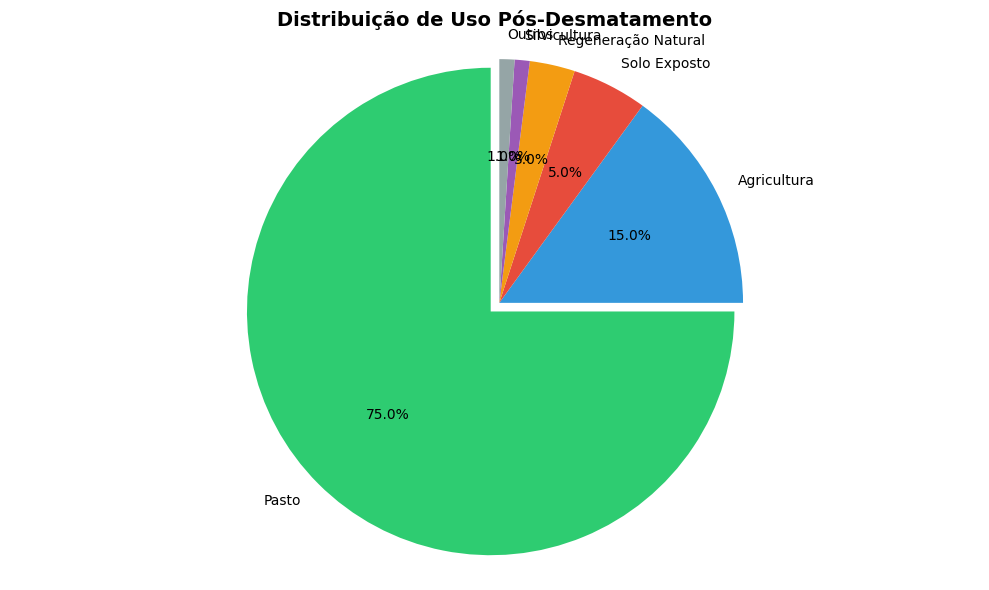

2026-05-16 14:57:14,736 - INFO -   Gráfico gerado: gráfico de pizza da distribuição de uso pós-desmatamento


In [7]:
logger.info("\n--- VISUALIZAÇÃO DA DISTRIBUIÇÃO ---")

# Visualizar distribuição de uso pós-desmatamento
plt.figure(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']
wedges, texts, autotexts = plt.pie(
    df_destinacao['Taxa_Conversao_Percentual'],
    labels=df_destinacao['Uso_Pós_Desmatamento'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=[0.05 if x > 50 else 0 for x in df_destinacao['Taxa_Conversao_Percentual']]
)

plt.title('Distribuição de Uso Pós-Desmatamento', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

logger.info("  Gráfico gerado: gráfico de pizza da distribuição de uso pós-desmatamento")

logger.info("\n--- CONCLUSÃO DA ANÁLISE 2 ---")

# Preencher conclusão com base nos resultados
uso_predominante = df_destinacao.iloc[0]
taxa_predominante = uso_predominante['Taxa_Conversao_Percentual']

### Conclusão da Análise 2

**Interpretação de Negócio:**
- O uso predominante pós-desmatamento é [uso com maior taxa]
- Isso representa [XX]% do total de áreas desmatadas
- Isso indica que [pecuária/agricultura] é o principal vetor de desmatamento

**Implicações para Políticas Públicas:**
- [Recomendações específicas baseadas na destinação predominante]
- [Foco em setor específico para contenção do desmatamento]

logger.info(f"\n  RESUMO EXECUTIVO:")
logger.info(f"  • Uso predominante: {uso_predominante['Uso_Pós_Desmatamento']} ({taxa_predominante:.2f}%)")
logger.info(f"  • Concentração de uso: {'ALTA' if taxa_predominante > 60 else 'MODERADA' if taxa_predominante > 30 else 'BAIXA'}")
logger.info(f"  • Vetor principal: {'Pecuária' if uso_predominante['Uso_Pós_Desmatamento'] == 'Pasto' else 'Agricultura' if uso_predominante['Uso_Pós_Desmatamento'] == 'Agricultura' else 'Outro'}")

logger.warning("\n  ⚠ LEMBRETE: Análise baseada em dados SIMULADOS")
logger.warning("  ⚠ Substituir por dados TerraClass reais para análise conclusiva")

---
## Resumo do Eixo 2: Uso e Transição do Solo

**Principais Descobertas:**
1. Estabilidade das classes de uso do solo: [classes mais/menos estáveis]
2. Destinação pós-desmatamento: [uso predominante e proporção]

**Implicações de Negócio:**
- [Insights sobre dinâmica de uso do solo]
- [Setores prioritários para intervenção]

**Próximos Passos:**
- [Análises adicionais recomendadas]
- [Integração com outros eixos, ex: Economia]

logger.info("\n" + "="*80)
logger.info("FIM DO EIXO 2: Uso e Transição do Solo")
logger.info("="*80)